# Milestone 3 - Credit Risk Analysis Project
# Predicting Credit Risk for Loan Approval Decisions
### Shaghayegh Malekshahi
### Bellevue University
#### March 2026


In [1]:
# import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
# Load the dataset

file_path = "german_credit_data.csv"

df = pd.read_csv(file_path)

print("First 5 rows:")
display(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad



Shape of dataset:
(1000, 11)

Column names:
['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']

Data types:
Unnamed: 0           int64
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object

Missing values:
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64


In [3]:
# Basic cleaning
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("\nUpdated shape after cleanup:")
print(df.shape)

print("\nUnique values in Risk:")
print(df["Risk"].value_counts())
df.columns = df.columns.str.strip()


Updated shape after cleanup:
(1000, 10)

Unique values in Risk:
Risk
good    700
bad     300
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

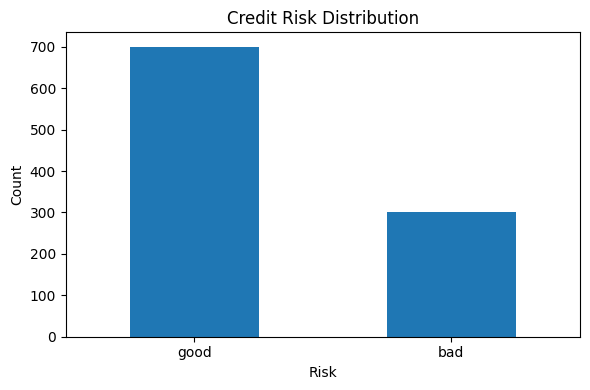

In [4]:
# a. Target distribution
plt.figure(figsize=(6, 4))
df["Risk"].value_counts().plot(kind="bar")
plt.title("Credit Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

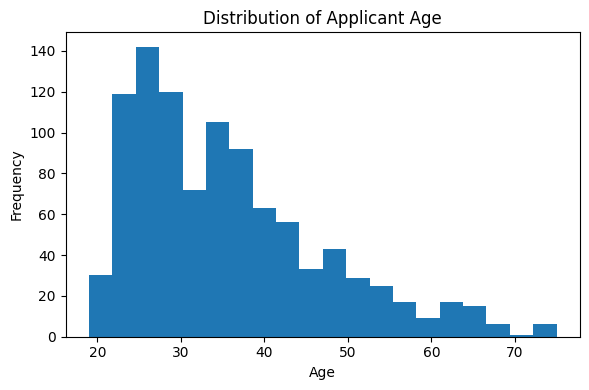

In [5]:
# b. Distribution of age
plt.figure(figsize=(6, 4))
plt.hist(df["Age"], bins=20)
plt.title("Distribution of Applicant Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

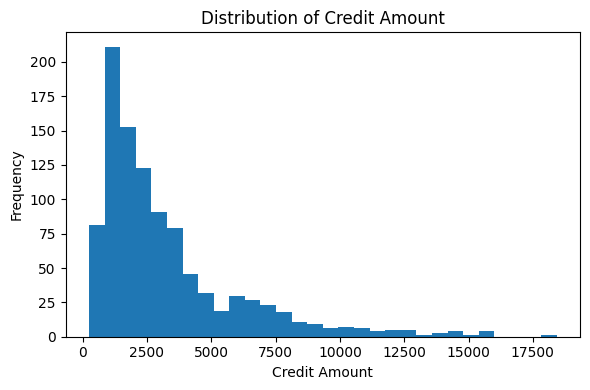

In [6]:
# c. Distribution of credit amount
plt.figure(figsize=(6, 4))
plt.hist(df["Credit amount"], bins=30)
plt.title("Distribution of Credit Amount")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

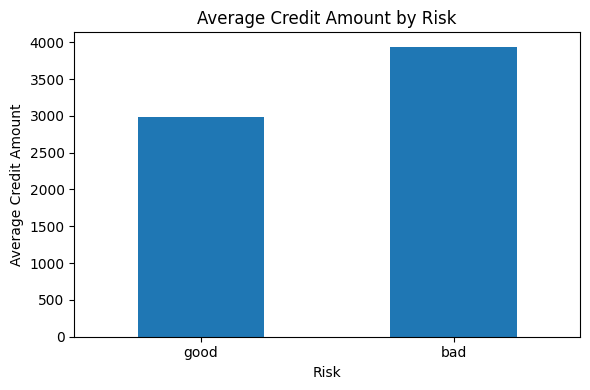

In [7]:
# d. Average credit amount by risk
avg_credit_by_risk = df.groupby("Risk")["Credit amount"].mean().sort_values()

plt.figure(figsize=(6, 4))
avg_credit_by_risk.plot(kind="bar")
plt.title("Average Credit Amount by Risk")
plt.xlabel("Risk")
plt.ylabel("Average Credit Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

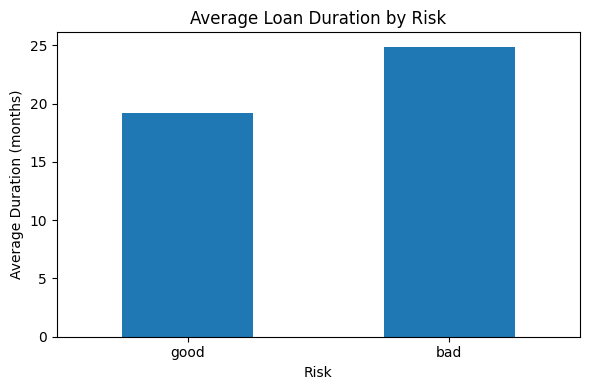

In [8]:
# e. Average loan duration by risk
avg_duration_by_risk = df.groupby("Risk")["Duration"].mean().sort_values()

plt.figure(figsize=(6, 4))
avg_duration_by_risk.plot(kind="bar")
plt.title("Average Loan Duration by Risk")
plt.xlabel("Risk")
plt.ylabel("Average Duration (months)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

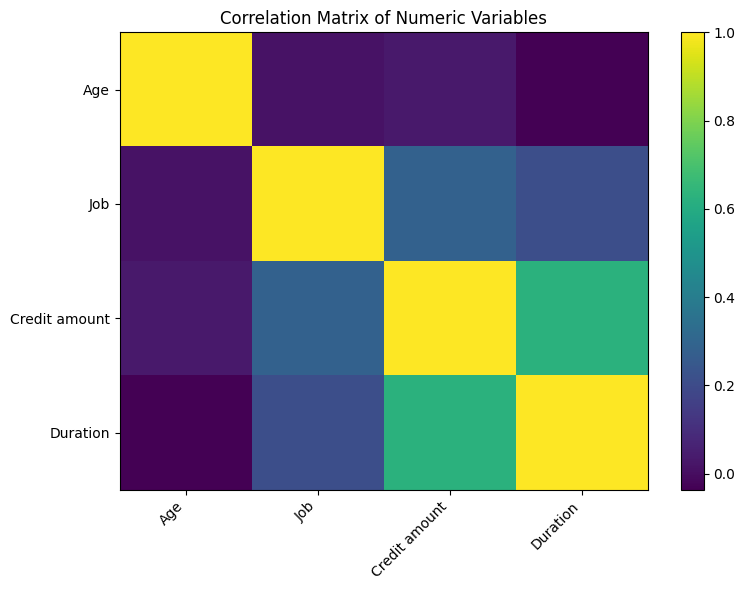


Summary statistics:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


In [9]:
# f. Numeric correlation matrix
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, interpolation="nearest", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

print("\nSummary statistics:")
display(df.describe(include="all"))

## Prepare data for modeling

In [10]:
# Convert target variable to binary
# good = 0, bad = 1
df["Risk"] = df["Risk"].map({"good": 0, "bad": 1})

print("\nMapped target values:")
print(df["Risk"].value_counts())

X = df.drop("Risk", axis=1)
y = df["Risk"]

# Identify column types
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

# Preprocessing for numeric columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Mapped target values:
Risk
0    700
1    300
Name: count, dtype: int64

Categorical features:
['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

Numerical features:
['Age', 'Job', 'Credit amount', 'Duration']

Training set shape: (800, 9)
Testing set shape: (200, 9)


## Logistic Regression Model


Logistic Regression Results
Accuracy: 0.745

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.95      0.84       140
           1       0.70      0.27      0.39        60

    accuracy                           0.74       200
   macro avg       0.72      0.61      0.61       200
weighted avg       0.73      0.74      0.70       200



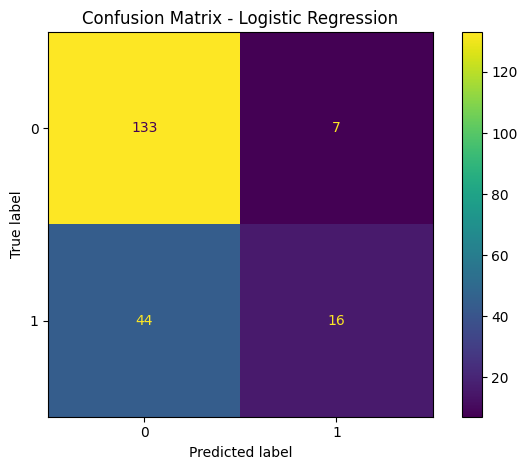

In [11]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("\n==============================")
print("Logistic Regression Results")
print("==============================")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp_log.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

## Decision Tree Model


Decision Tree Results
Accuracy: 0.7

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.94      0.81       140
           1       0.50      0.15      0.23        60

    accuracy                           0.70       200
   macro avg       0.61      0.54      0.52       200
weighted avg       0.65      0.70      0.64       200



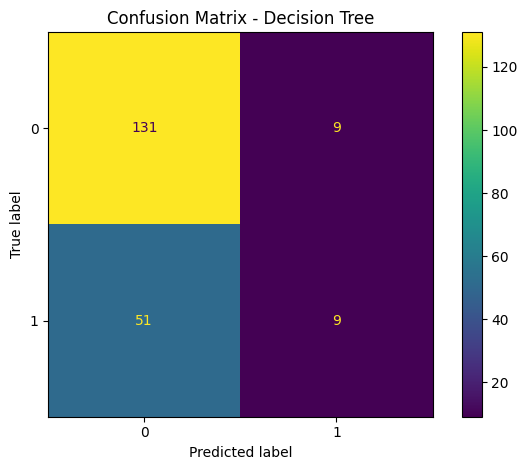

In [12]:
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("\n==============================")
print("Decision Tree Results")
print("==============================")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp_tree.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()

## Compare model performance


Model Comparison:


,Model,Accuracy
0,Logistic Regression,0.745
1,Decision Tree,0.700


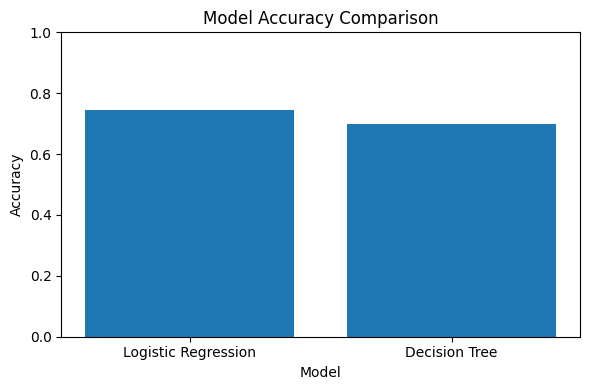

In [13]:
log_accuracy = accuracy_score(y_test, y_pred_log)
tree_accuracy = accuracy_score(y_test, y_pred_tree)

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [log_accuracy, tree_accuracy]
})

print("\nModel Comparison:")
display(comparison_df)

plt.figure(figsize=(6, 4))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Feature importance from logistic regression


Top 10 most influential features (Logistic Regression):


,Feature,Coefficient
12,Saving accounts_rich,-0.634708
19,Purpose_education,0.615170
9,Saving accounts_little,0.471012
3,Duration,0.466022
23,Purpose_vacation/others,-0.459763
21,Purpose_radio/TV,-0.458286
10,Saving accounts_moderate,0.414423
22,Purpose_repairs,0.360532
7,Housing_own,-0.311498
14,Checking account_moderate,0.298841


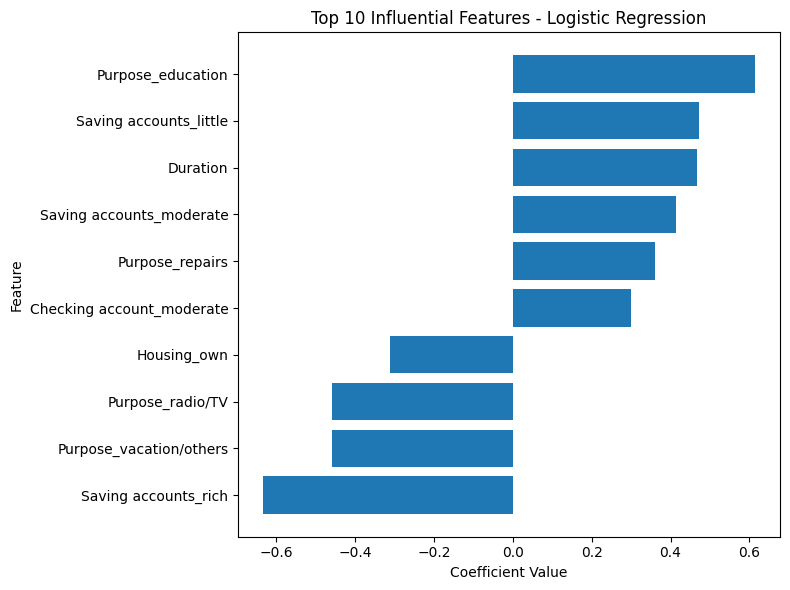

In [14]:
# Get transformed feature names
ohe = log_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([numerical_features, cat_feature_names])

# Logistic regression coefficients
coefficients = log_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients
})

coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoefficient", ascending=False)

print("\nTop 10 most influential features (Logistic Regression):")
display(coef_df[["Feature", "Coefficient"]].head(10))

top_10 = coef_df.head(10).sort_values("Coefficient")

plt.figure(figsize=(8, 6))
plt.barh(top_10["Feature"], top_10["Coefficient"])
plt.title("Top 10 Influential Features - Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## visualize a small decision tree

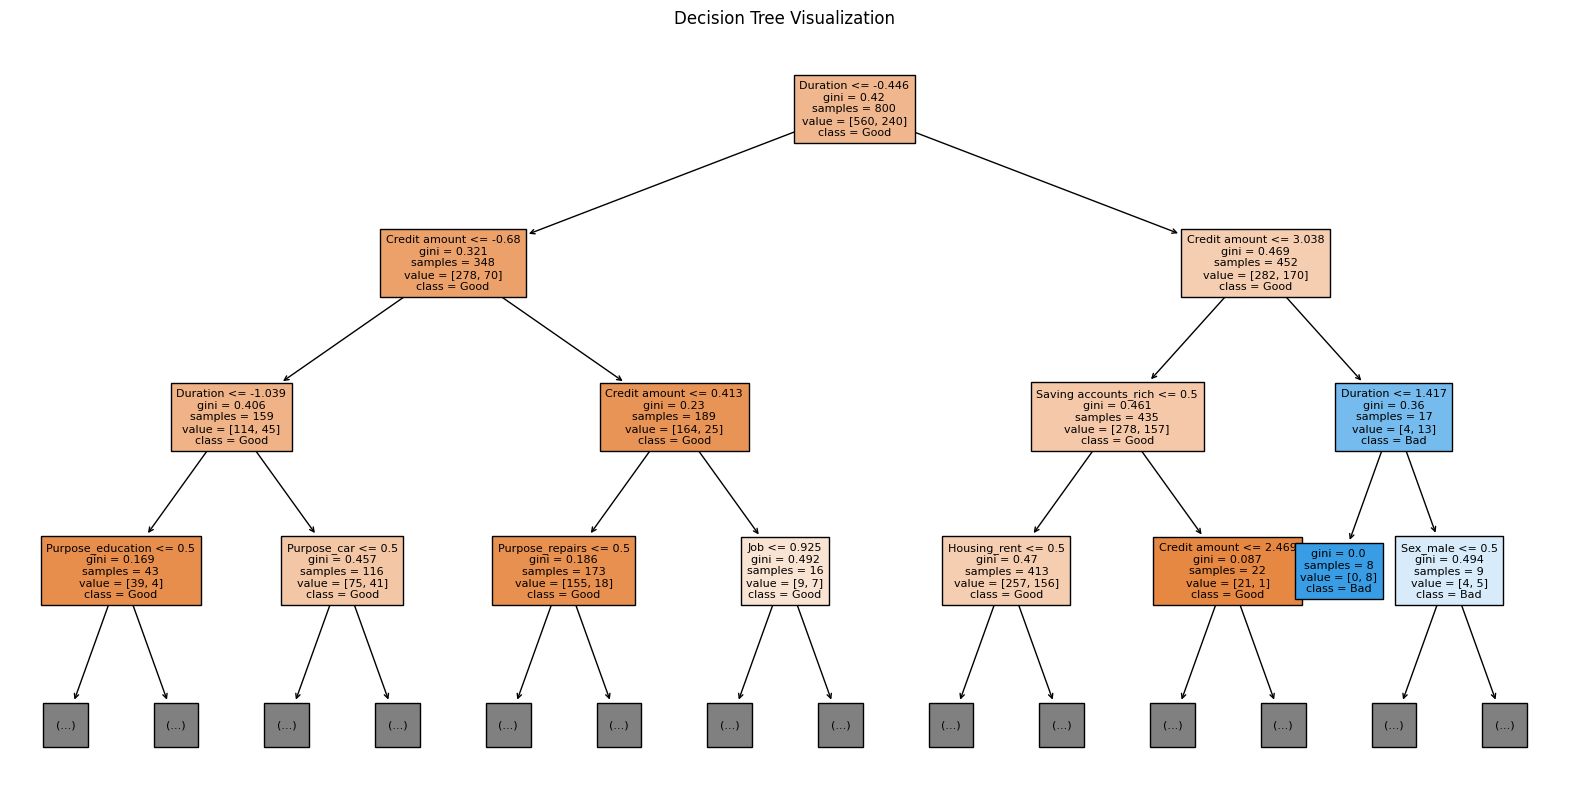

In [15]:
# To plot the tree, we need the transformed data
X_train_processed = tree_model.named_steps["preprocessor"].transform(X_train)

# For plotting feature names again
tree_feature_names = all_feature_names

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model.named_steps["classifier"],
    filled=True,
    feature_names=tree_feature_names,
    class_names=["Good", "Bad"],
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree Visualization")
plt.show()

## Final interpretation summary

In [16]:
best_model = "Logistic Regression" if log_accuracy >= tree_accuracy else "Decision Tree"

print("\n========================================")
print("Final Summary")
print("========================================")
print(f"Best performing model based on accuracy: {best_model}")
print(f"Logistic Regression Accuracy: {log_accuracy:.4f}")
print(f"Decision Tree Accuracy: {tree_accuracy:.4f}")

print("\nProject conclusion:")
print(
    "This analysis shows that machine learning can be used to classify credit risk "
    "using applicant financial and demographic information. The results provide a useful "
    "foundation for understanding borrower risk and supporting loan approval decisions."
)


Final Summary
Best performing model based on accuracy: Logistic Regression
Logistic Regression Accuracy: 0.7450
Decision Tree Accuracy: 0.7000

Project conclusion:
This analysis shows that machine learning can be used to classify credit risk using applicant financial and demographic information. The results provide a useful foundation for understanding borrower risk and supporting loan approval decisions.
